# Esercizi - Lezione 4
# Hardware acceleration, keras, hyperparametrization

## Multithreading

Ci sono tre modi di parallilizzare sulle CPU:
- Instruction-level Parallelism (ILP), automatica da parte della CPU
- Istruzione singola, Molti dati (SIMD)
- Thread-Level Parallelism (TLP), uso di compilers e librerie

Posso fare cicli for in parallelo.

Posso anche fare multithreading sulla gpu, che e' tendenzialmente più veloce della CPU.



## Esercizio 1 - Regressione con un modello sequenziale

- Legge il file data.dat e salva i dati
- Plotta i dati per training e validation
- Crea un modello lineare di baseline e salva l'istanza della calsse in una variabile `model`

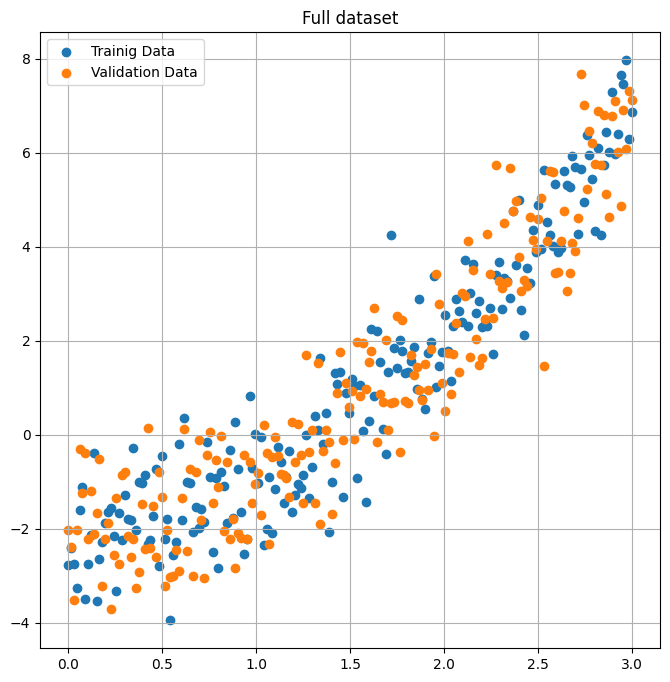

In [44]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

data = np.loadtxt('data.dat')

x_tr = data[:, 0]
y_tr = data[:, 1]
x_val = data[:, 2]
y_val = data[:, 3]


plt.figure(figsize=(8,8))
plt.scatter(x_tr, y_tr, colorizer='orange', label='Trainig Data')
plt.scatter(x_val, y_val, colorizer='green', label='Validation Data')
plt.legend()
plt.title("Full dataset")
plt.grid('both')

In [45]:
model = tf.keras.Sequential()

model.add(tf.keras.layers.Input(shape=(1,)))
model.add(tf.keras.layers.Dense(1))

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),  
              loss=tf.keras.losses.MeanSquaredError)

history = model.fit(x_tr, y_tr, 
                    batch_size=x_tr.shape[0], 
                    epochs=500,
                    validation_data = (x_val, y_val))

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - loss: 15.5828 - val_loss: 14.0035
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 14.1125 - val_loss: 12.7596
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 12.8525 - val_loss: 11.6940
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 11.7721 - val_loss: 10.7807
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 10.8449 - val_loss: 9.9971
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 10.0486 - val_loss: 9.3244
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 9.3641 - val_loss: 8.7462
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 8.7749 - val_loss: 8.2486
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 8.2671 - val_loss: 7.8199
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 7.8289 - val_loss: 7.4498
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 7.4501 - val_loss: 7.1299
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 7.12

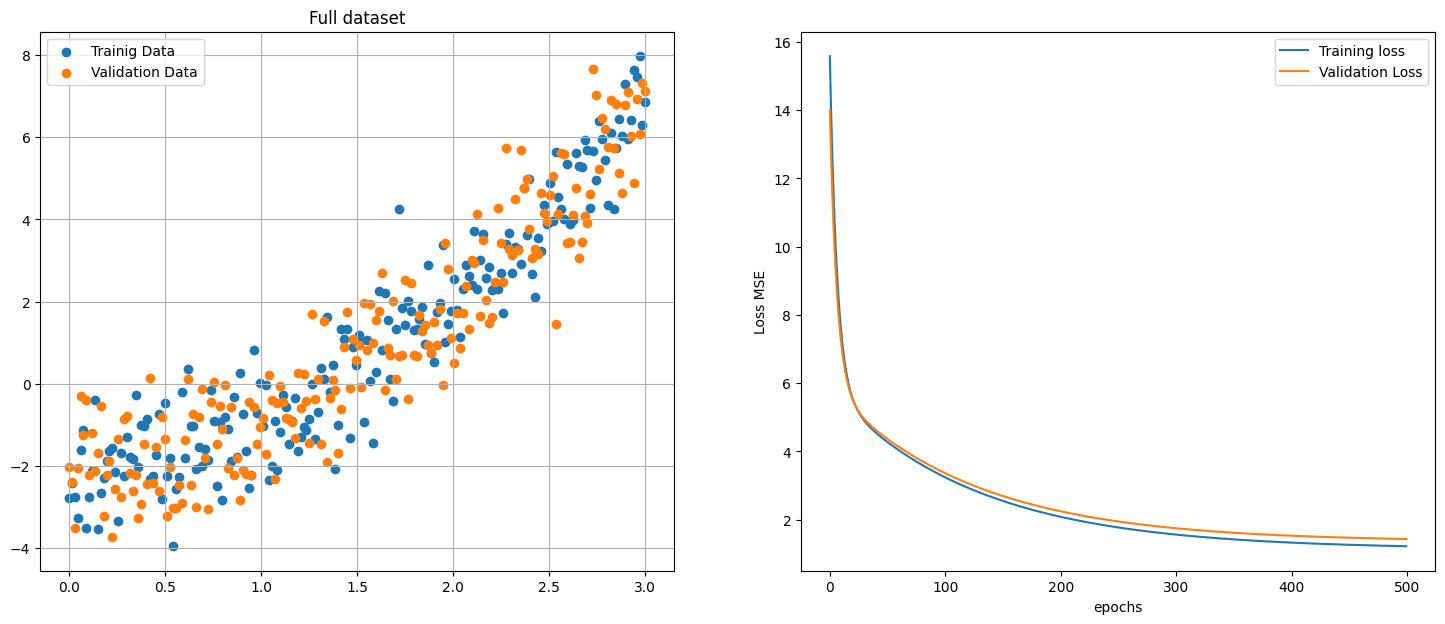

In [46]:

fig = plt.figure(figsize=(18,7))
a = plt.subplot(1,2,1)
plt.scatter(x_tr, y_tr, colorizer='orange', label='Trainig Data')
plt.scatter(x_val, y_val, colorizer='green', label='Validation Data')
plt.legend()
plt.title("Full dataset")
plt.grid('both')
a = plt.subplot(1,2,2)

def plot_history(history):
    plt.plot(history.epoch, history.history['loss'], label='Training loss')
    plt.plot(history.epoch, history.history['val_loss'], label = 'Validation Loss')
    plt.xlabel("epochs")
    plt.ylabel("Loss MSE")
    plt.legend()

plot_history(history)

Creiamo un modello di neural network

In [47]:
model2 = tf.keras.Sequential()
model2.add(tf.keras.layers.Input(shape=(1,)))
model2.add(tf.keras.layers.Dense(10, activation='relu'))
model2.add(tf.keras.layers.Dense(10, activation='relu'))
model2.add(tf.keras.layers.Dense(10, activation='relu'))
model2.add(tf.keras.layers.Dense(1))

model2.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),  
              loss=tf.keras.losses.MeanSquaredError)

history2 = model2.fit(x_tr, y_tr, 
                      batch_size=x_tr.shape[0], 
                      epochs=500, 
                      validation_data=(x_val,y_val))

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - loss: 14.4151 - val_loss: 9.5621
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 9.6065 - val_loss: 8.1648
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 8.1826 - val_loss: 7.1331
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 7.1275 - val_loss: 6.3120
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 6.2837 - val_loss: 5.6784
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 5.6281 - val_loss: 5.2276
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 5.1573 - val_loss: 4.8100
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 4.7111 - val_loss: 4.6812
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 4.5727 - val_loss: 4.5794
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 4.4638 - val_loss: 4.4881
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 4.3674 - val_loss: 4.3981
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 4.2738 - val_

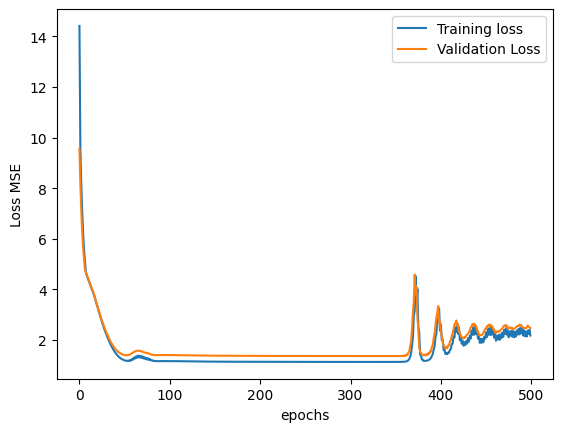

In [48]:
plot_history(history2)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


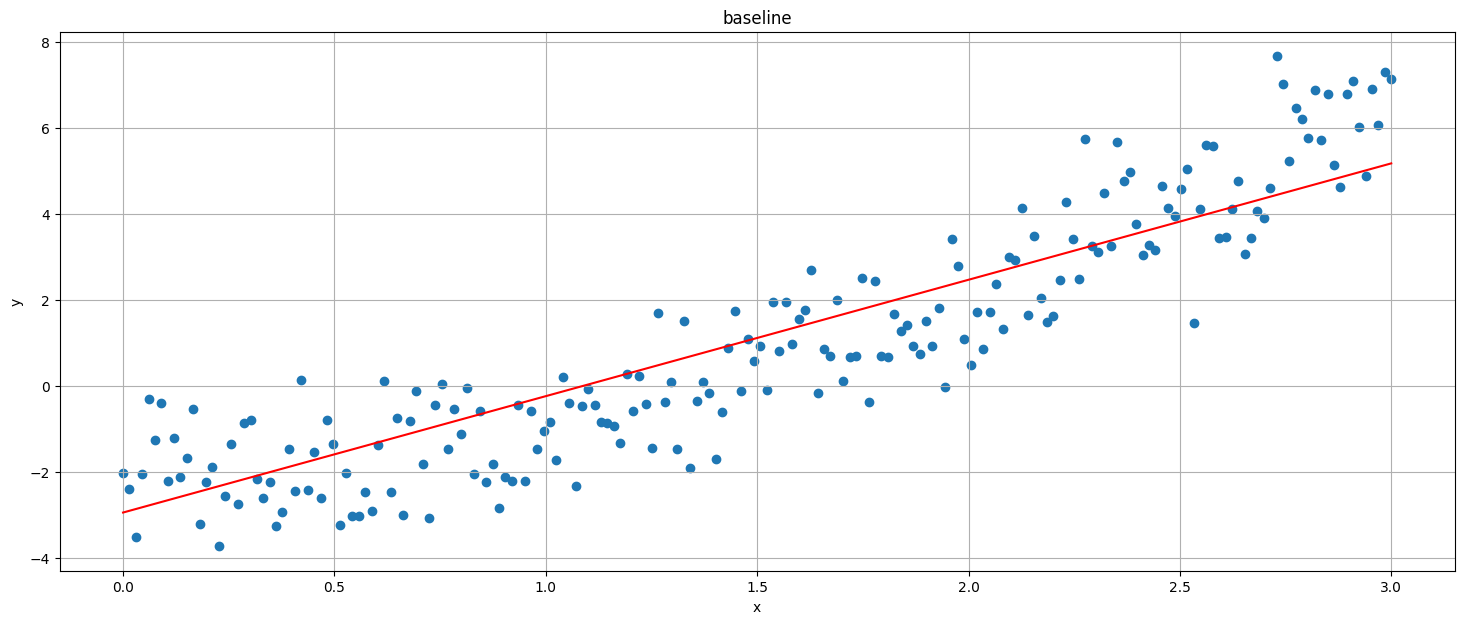

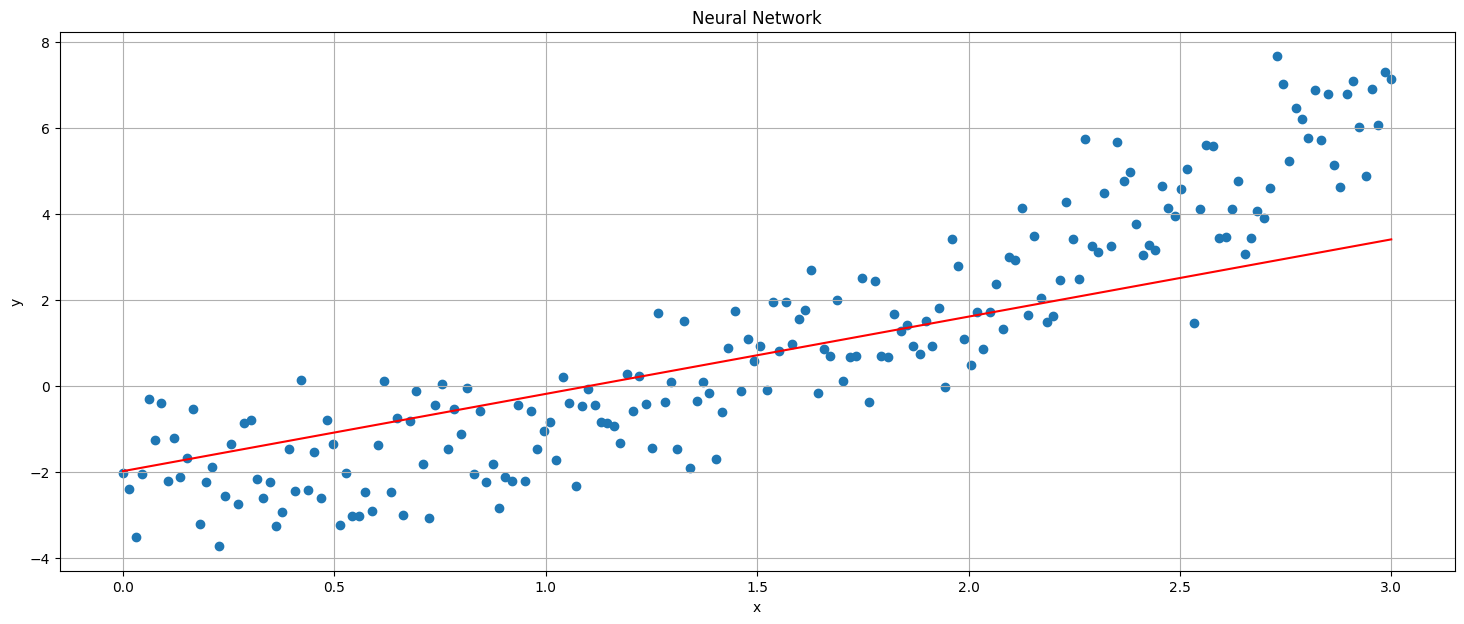

In [49]:
def plot_result(x, y, y_pred, title):
    plt.figure(figsize=(18,7))
    plt.scatter(x, y)
    plt.plot(x, y_pred, color="red")
    plt.grid()
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")

plot_result(x_val, y_val, model.predict(x_val), "baseline")
plot_result(x_val, y_val, model2.predict(x_val), "Neural Network")

Credo che ci sia qualche errore perche non credo che il secondo plot sia lineare
